# 使用推断 GRN 运行 RegVelo

本教程演示如何在 OmicVerse 中使用 RegVelo 官方 zebrafish neural crest RNA velocity 数据运行 RegVelo。这个 AnnData 已经包含 `spliced` 和 `unspliced` layer，以及 `cell_type`、`stage` 和 `var["is_tf"]` 注释；但本教程不使用官方预置 GRN，而是把它当作一个干净的 velocity 数据集，从表达矩阵直接推断 TF-target prior GRN。

流程如下：

1. 读取 RegVelo 官方 `zebrafish_nc()` velocity 数据；
2. 筛选基因集合，同时保留全部 TF；
3. 用 `ov.single.grn()` 从表达矩阵推断真实 TF-target prior GRN，默认示例使用 GRNBoost2，也可切换为 GENIE3 或 RegDiffusion；
4. 调用 `Velo.prepare_regvelo()` 计算 `Ms` / `Mu` moment layers，并把 prior 对齐到 `adata.uns["skeleton"]`；
5. 训练 RegVelo，投影 velocity field，并继续做 CellRank 和扰动分析。

需要注意：下面的 prior 由 GRNBoost2 从当前 zebrafish 表达矩阵推断得到；如果有 ATAC/motif、ChIP 或 curated TF-target database，也可以替换为这些外部证据支持的 prior。

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import scipy.sparse as sp
import torch
import regvelo as rgv
import warnings

import omicverse as ov

warnings.filterwarnings("ignore", category=FutureWarning)
ov.plot_set(font_path="Arial")

RESULT_DIR = Path("result/regvelo_infer_grn")
RESULT_DIR.mkdir(parents=True, exist_ok=True)

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 读取 RegVelo 官方 velocity 数据

`rgv.datasets.zebrafish_nc()` 读取 RegVelo 官方 zebrafish neural crest 示例数据。这里仅使用其中的干净 AnnData 表达和注释信息：`spliced` / `unspliced` layer 用于 velocity moments，`obs["cell_type"]` 用于下游 CellRank 和可视化，`var["is_tf"]` 用于定义候选 regulator。

In [2]:
adata = rgv.datasets.zebrafish_nc().copy()
adata.var_names_make_unique()

print(adata)
print("layers:", list(adata.layers.keys()))
print("obs columns:", list(adata.obs.columns))
print("obsm keys:", list(adata.obsm.keys()))
print("TF annotations:", int(adata.var["is_tf"].astype(bool).sum()))

AnnData object with n_obs × n_vars = 697 × 8012
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'is_tf'
    uns: 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'
layers: ['ambiguous', 'matrix', 'spliced', 'unspliced']
obs columns: ['initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage']
obsm keys: ['X_pca', 'X_umap']
TF annotations: 125


## 控制基因规模并定义候选调控因子

GRN 推断和 RegVelo 训练都不适合在教程中直接使用全基因空间。这里保留 spliced 表达中变异最高的一组基因，并强制保留 `var["is_tf"]` 标记的所有 TF。这样既保持教程运行规模可控，也避免后续 TF perturbation 时关键 regulator 被提前过滤掉。

In [3]:
n_top_genes = 2500
spliced = adata.layers["spliced"]
spliced = spliced.toarray() if sp.issparse(spliced) else np.asarray(spliced)

gene_means = spliced.mean(axis=0)
gene_vars = spliced.var(axis=0)
expressed_idx = np.where(gene_means > 0)[0]
ranked_idx = expressed_idx[np.argsort(gene_vars[expressed_idx])]
hvg_idx = ranked_idx[-min(n_top_genes, len(ranked_idx)):]

tf_mask = adata.var["is_tf"].astype(bool).to_numpy()
tf_idx = np.where(tf_mask)[0]
keep_idx = np.union1d(hvg_idx, tf_idx)
adata = adata[:, keep_idx].copy()

regulators = adata.var_names[adata.var["is_tf"].astype(bool)].tolist()
print("genes kept:", adata.n_vars)
print("candidate TFs:", len(regulators))
print("example TFs:", regulators[:10])

genes kept: 2555
candidate TFs: 125
example TFs: ['otx1', 'twist1b', 'jdp2a', 'otx2a', 'alx4a', 'erf', 'hoxa9a', 'hoxb10a', 'hnf1ba', 'sox19a']


## 使用 GRN 推断 prior

RegVelo 需要的是 `TF`、`target`、`importance` 格式的 prior edge list。OmicVerse 提供了直接入口 `ov.single.grn()`，可以从 AnnData 表达矩阵返回这个三列表格；设置 `key_added` 时也会把结果写入 `adata.uns`：

- `ov.single.grn(method="grnboost2")`：arboreto/GRNBoost2 tree-based TF-target inference，适合作为教程默认选择；
- `ov.single.grn(method="genie3")`：GENIE3/random forest TF-target inference；
- `ov.single.grn(method="regdiffusion")`：调用 RegDiffusion 推断 GRN，计算更重，建议先限制 HVG 或基因集合，并确认已安装 `regdiffusion`。

In [4]:
prior_edges = ov.single.grn(
    adata,
    method="grnboost2",
    regulators=regulators,
    layer="spliced",
    top=120,
    seed=42,
    n_workers=2,
    threads=2,
    key_added="grnboost2_prior",
)

prior_edges = adata.uns["grnboost2_prior"]
prior_edges.to_csv(RESULT_DIR / "zebrafish_grnboost2_prior.csv", index=False)
prior_edges.head()

      TF   target  importance
0  zic2b     lfng   14.689011
1  zic2b    gdf6a   14.138430
2  zic2b  tuba8l3   13.809170
3  zic2b    pax3a   13.774076
4  zic2b    sox9b   13.505762

In [5]:
print("GRN method: GRNBoost2")
print("prior edges:", prior_edges.shape)
print("TFs in prior:", prior_edges["TF"].nunique())
print("targets in prior:", prior_edges["target"].nunique())
print("saved in adata.uns:", "grnboost2_prior" in adata.uns)
print("GRN metadata:", adata.uns["grnboost2_prior_params"])
print("saved prior:", RESULT_DIR / "zebrafish_grnboost2_prior.csv")
print(prior_edges.groupby("TF")["target"].nunique().sort_values(ascending=False).head(10))

GRN method: GRNBoost2
prior edges: (15000, 3)
TFs in prior: 125
targets in prior: 2532
saved in adata.uns: True
GRN metadata: {'method': 'grnboost2', 'layer': 'spliced', 'top': 120, 'log': True, 'seed': 42, 'n_workers': 2, 'threads': 2, 'n_edges': 15000, 'n_regulators': 125}
saved prior: result/regvelo_infer_grn/zebrafish_grnboost2_prior.csv
TF
alx4a       120
nr4a2b      120
roraa       120
rarga       120
pparab      120
pknox2      120
pknox1.2    120
pbx1a       120
pax2b       120
patz1       120
Name: target, dtype: int64


## 计算 `Ms` / `Mu` 并对齐 prior GRN

`Velo.prepare_regvelo()` 是 OmicVerse 中的 RegVelo 准备步骤。它会计算 neighbors 和 moments，生成 `Ms`、`Mu`，并进行基因预处理，把边表 prior 对齐到最终保留的基因集合，并写入 `adata.uns["skeleton"]`。

In [6]:
velo_prep = ov.single.Velo(adata)
prior_grn, regulators = velo_prep.prepare_regvelo(
    prior_edges,
    regulators=regulators,
    n_neighbors=30,
    n_pcs=50,
    moment_backend="scvelo",
    prior_orientation="target_by_regulator",
)
adata = velo_prep.adata

print(adata)
print("layers:", list(adata.layers.keys()))
print("Ms/Mu present:", "Ms" in adata.layers, "Mu" in adata.layers)
print("prior GRN shape:", prior_grn.shape)
print("retained regulators:", len(regulators), regulators[:10])
print("RegVelo prep metadata:", adata.uns["regvelo_prepare"])

In Velo module, you should keep all genes' expression not normalized.
🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 30
   Method: umap
   Metric: euclidean
   PCs used: 50
   🔍 Computing neighbor distances...
   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 697 cells with 30 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 1.9906s                                                 │
│  Shape:    697 x 2,555 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighb

AnnData object with n_obs × n_vars = 697 × 997
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'is_tf', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'cell_type_colors', 'grnboost2_prior', 'grnboost2_prior_params', 'neighbors', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'velocity_params', 'regulators', 'targets', 'skeleton', 'network', 'regvelo_prepare', 'regvelo_regulators'
    obsm: 'X_pca', 'X_umap'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity'
    obsp: 'distances', 'connectivities'
layers: ['ambiguous', 'matrix', 'spliced', 'unspliced', 'Ms', 'Mu', 'velocity']
Ms/Mu present: True True
prior GRN shape: (997, 997)
retained regulators: 81 ['alx4a', 'alx4b', 'arntl1b', 'bach2b', 'bhlhe40', 'bhlhe41', 'dlx1a', 'e2f7', 'ebf1b', 'ebf3a']
RegVelo prep metadata: {'n_neighb

## 运行 RegVelo

下一步会训练 RegVelo，并把推断出的 velocity 写入 `layers["velo_regvelo"]`。如果只是快速测试，可以降低 `max_epochs`；正式分析应提高 epochs 并检查收敛情况。


In [7]:
if torch.cuda.is_available():
    accelerator = "gpu"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    accelerator = "mps"
else:
    accelerator = "cpu"

adata = ov.single.velocity(
    adata,
    method="regvelo",
    prior_grn=prior_grn,
    regulators=regulators,
    velocity_key="velo_regvelo",
    spliced_layer="Ms",
    unspliced_layer="Mu",
    n_samples=30,
    model_save_path=str(RESULT_DIR / "model"),
    model_overwrite=True,
    regvelo_kwargs={
        "soft_constraint": False,
    },
    train_kwargs={
        "max_epochs": 50,
        "accelerator": accelerator,
        "devices": 1,
    },
    compute_velocity_graph=True,
    compute_velocity_embedding=True,
    basis="umap",
    graph_kwargs={
        "xkey": "Ms",
        "n_jobs": 4,
    },
)

print(adata.uns["regvelo"])
print("velocity layers:", [key for key in adata.layers.keys() if "velo" in key or key == "velocity"])
print("velocity embeddings:", [key for key in adata.obsm.keys() if "velo" in key])

GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In Velo module, you should keep all genes' expression not normalized.


Training:   0%|          | 0/50 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


computing velocity graph (using 4/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:04) --> added 
    'velo_regvelo_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velo_regvelo_umap', embedded velocity vectors (adata.obsm)
{'spliced_layer': 'Ms', 'unspliced_layer': 'Mu', 'n_samples': 30, 'batch_size': 697, 'velocity_key': 'velo_regvelo', 'n_regulators': 81, 'model_load_path': None, 'model_save_path': 'result/regvelo_infer_grn/model', 'model_overwrite': True, 'reuse_regvelo_output': False, 'reused_regvelo_output': False}
velocity layers: ['velocity', 'latent_time_velovi', 'velo_regvelo']
velocity embeddings: ['velo_regvelo_umap']


## 可视化 RegVelo vector field

zebrafish 数据中主要的细胞状态注释是 `obs["cell_type"]`。这里用 `ov.pl.embedding()` 绘制细胞嵌入，再用 `ov.pl.add_streamplot()` 叠加 `obsm["velo_regvelo_umap"]` 中的 RegVelo vector field。

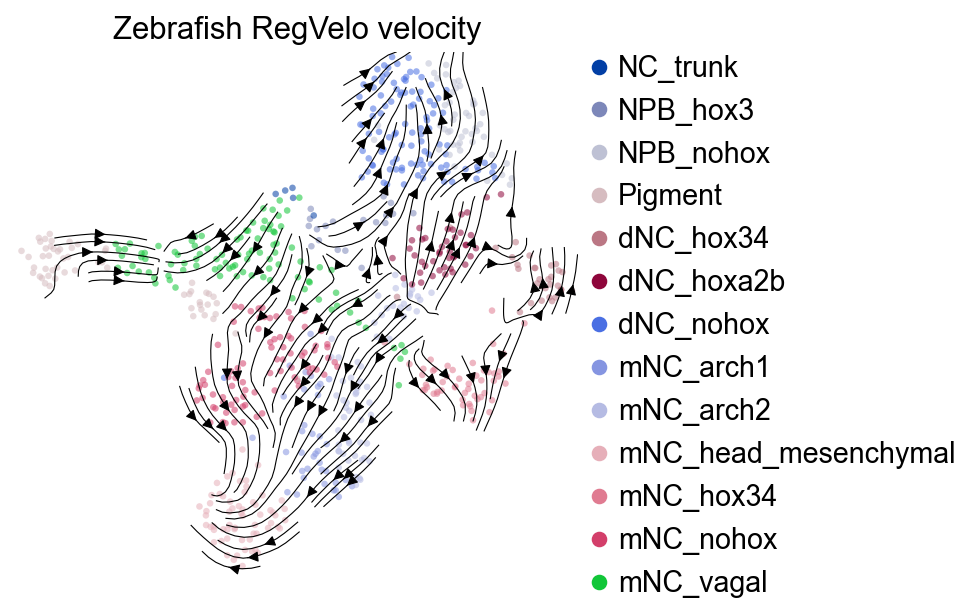

In [8]:
fig = ov.plt.figure(figsize=(4.5, 4.5))
ax = ov.plt.subplot(1, 1, 1)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_type",
    ax=ax,
    show=False,
    size=35,
    alpha=0.55,
    frameon=False,
)
ov.pl.add_streamplot(
    adata,
    basis="X_umap",
    velocity_key="velo_regvelo_umap",
    ax=ax,
)
ov.plt.title("Zebrafish RegVelo velocity")
ov.plt.show()

## 检查 latent time 和 regulon size

不同 RegVelo 版本导出的诊断 layer 可能略有差异。这里先检查是否存在 `fit_t`，再绘制 latent time；同时汇总 `adata.uns["skeleton"]` 中保留下来的 prior regulon 大小。


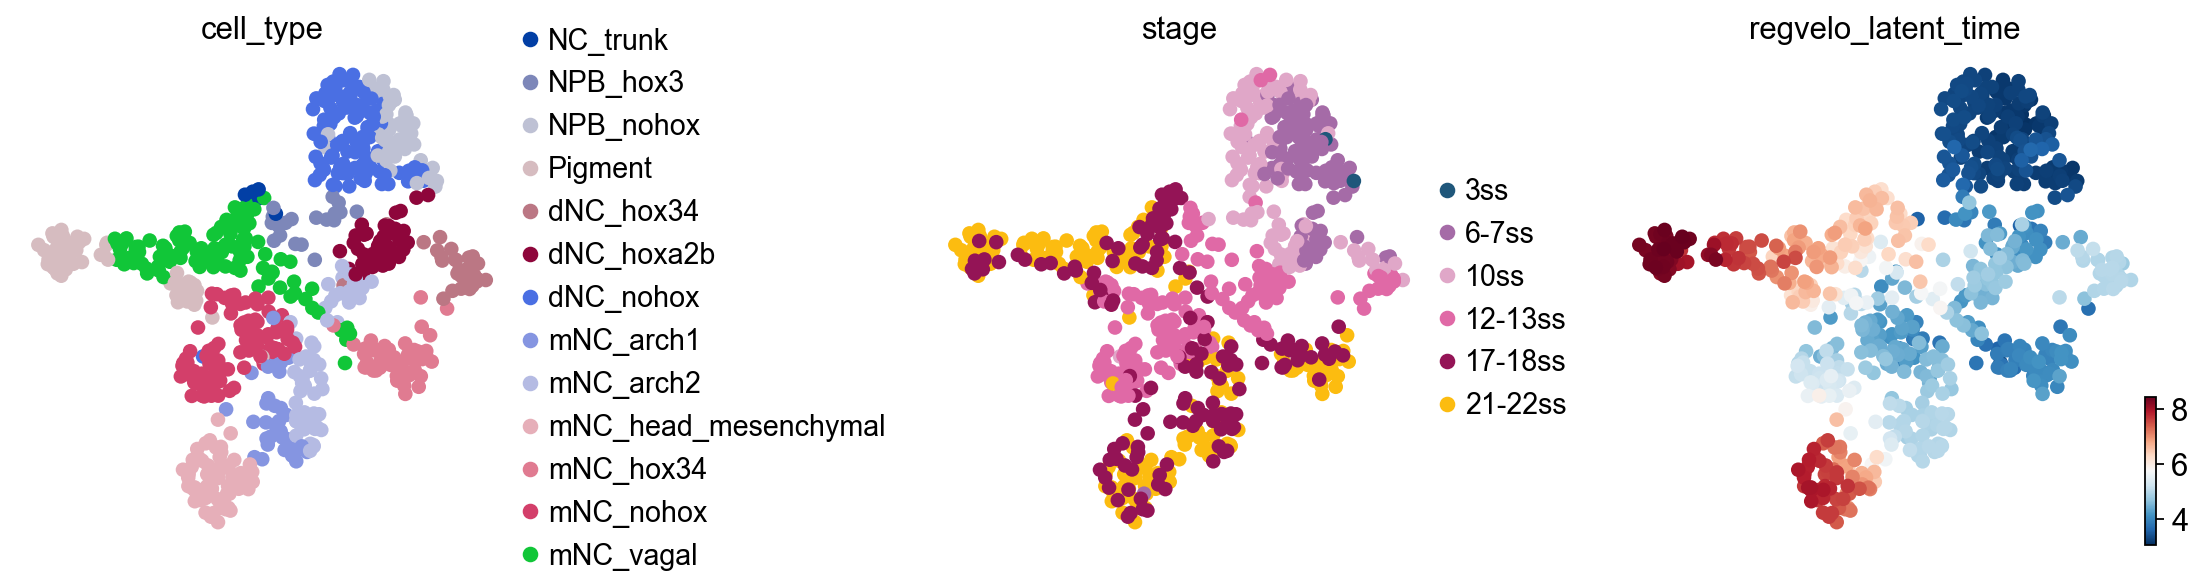

Gene
ppm1h                12
col12a1a             12
zgc:112332           12
hoxb5b               12
si:ch211-199g17.2    11
plpp3                11
tuba8l2              11
ptprfa               10
tcf12                10
msx3                 10
hoxa9b               10
sox9b                10
rflnb                10
efemp2b              10
cspg5a               10
dtype: int64

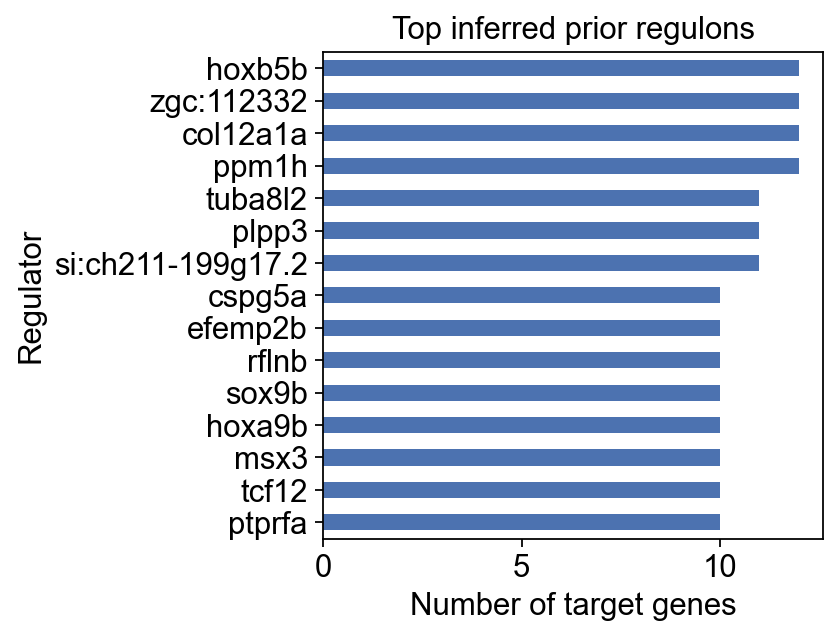

In [9]:
if "fit_t" in adata.layers:
    fit_t = np.asarray(adata.layers["fit_t"])
    adata.obs["regvelo_latent_time"] = fit_t.mean(axis=1)
    latent_colors = ["cell_type", "regvelo_latent_time"]
    if "stage" in adata.obs:
        latent_colors.insert(1, "stage")
    ov.pl.embedding(
        adata,
        basis="X_umap",
        color=latent_colors,
        ncols=min(3, len(latent_colors)),
        frameon=False,
        show=False,
    )
    ov.plt.show()
else:
    print("RegVelo did not export layers['fit_t'] in this run.")

skeleton = adata.uns["skeleton"]
if isinstance(skeleton, pd.DataFrame):
    regulon_size = (skeleton != 0).sum(axis=0).sort_values(ascending=False)
else:
    skeleton_array = np.asarray(skeleton)
    regulon_size = pd.Series(
        (skeleton_array != 0).sum(axis=0),
        index=adata.var_names[: skeleton_array.shape[1]],
    ).sort_values(ascending=False)

regulon_size_summary = regulon_size.head(15)
display(regulon_size_summary)

ax = regulon_size_summary.sort_values().plot.barh(figsize=(4, 4), color="#4c72b0")
ax.set_xlabel("Number of target genes")
ax.set_ylabel("Regulator")
ax.set_title("Top inferred prior regulons")
ov.plt.show()

## 基于 RegVelo velocity 的 CellRank fate analysis

zebrafish neural crest 数据的 `cell_type` 中包含多个 neural crest / pigment 相关状态。这里从一组保守 terminal states 开始，并只保留当前数据中实际存在的状态。

本节会直接计算 fate probabilities，后续 commitment score、fate probability shift 和 perturbation effect 都复用这些结果。

In [10]:
requested_terminal_states = ["mNC_head_mesenchymal", "mNC_hox34", "Pigment"]
requested_terminal_states = [state for state in requested_terminal_states if state in set(adata.obs["cell_type"])]
if not requested_terminal_states:
    raise ValueError("None of the requested terminal states were found in adata.obs['cell_type'].")

print("requested terminal states:", requested_terminal_states)

estimator = ov.single.cellrank_fate(
    adata,
    velocity_key="velo_regvelo",
    xkey="Ms",
    cluster_key="cell_type",
    terminal_states=requested_terminal_states,
    n_states=max(4, len(requested_terminal_states)),
    n_cells=30,
    connectivity_weight=0.2,
    compute_fate_probabilities=True,
    fate_kwargs={"solver": "direct", "use_petsc": False},
    clean=True,
    plot=False,
)

cellrank_state = adata.uns["velocity_cellrank"]
terminal_states = list(cellrank_state.get("terminal_states") or [])
if not terminal_states:
    raise ValueError(
        "None of the requested terminal states are CellRank macrostates. "
        f"Valid macrostates: {ov.single.state_names(estimator)}"
    )

macrostate_names = ov.single.state_names(estimator)
print("terminal states used:", terminal_states)
print("macrostates:", macrostate_names)

requested terminal states: ['mNC_head_mesenchymal', 'mNC_hox34', 'Pigment']
In Velo module, you should keep all genes' expression not normalized.


  0%|          | 0/697 [00:00<?, ?cell/s]

  0%|          | 0/697 [00:00<?, ?cell/s]

terminal states used: ['mNC_head_mesenchymal', 'Pigment']
macrostates: ['dNC_hox34', 'Pigment', 'mNC_head_mesenchymal', 'dNC_nohox']


`ov.pl.cell_fate()` 会复用 `adata.uns["velocity_cellrank"]["estimator"]` 中保存的 CellRank 结果。它只负责可视化 terminal states，不会重新计算 macrostates。

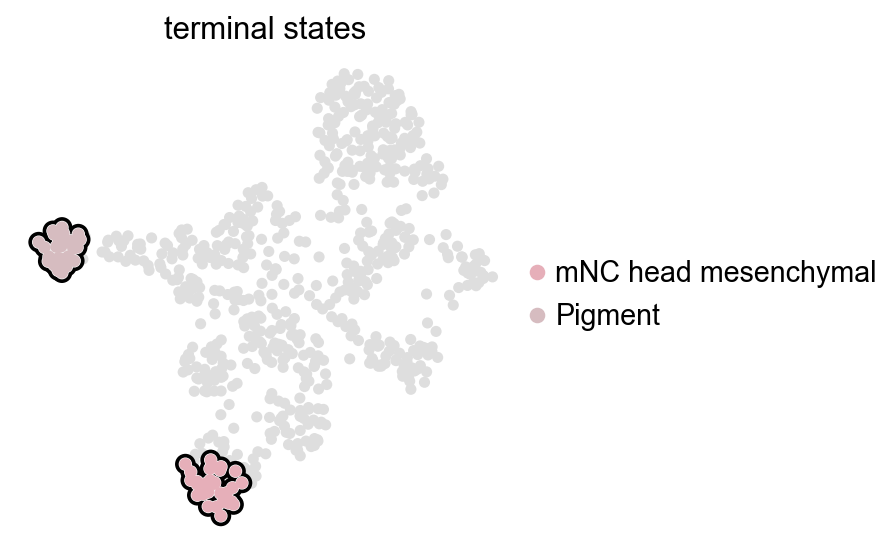

In [11]:
ov.pl.cell_fate(estimator, which="terminal", basis="umap")

## Fate probabilities 与 commitment score

CellRank 会计算每个细胞到 terminal states 的 fate probabilities。RegVelo 扰动流程也会使用这些概率计算 commitment score；数值越低通常表示细胞命运越 committed。

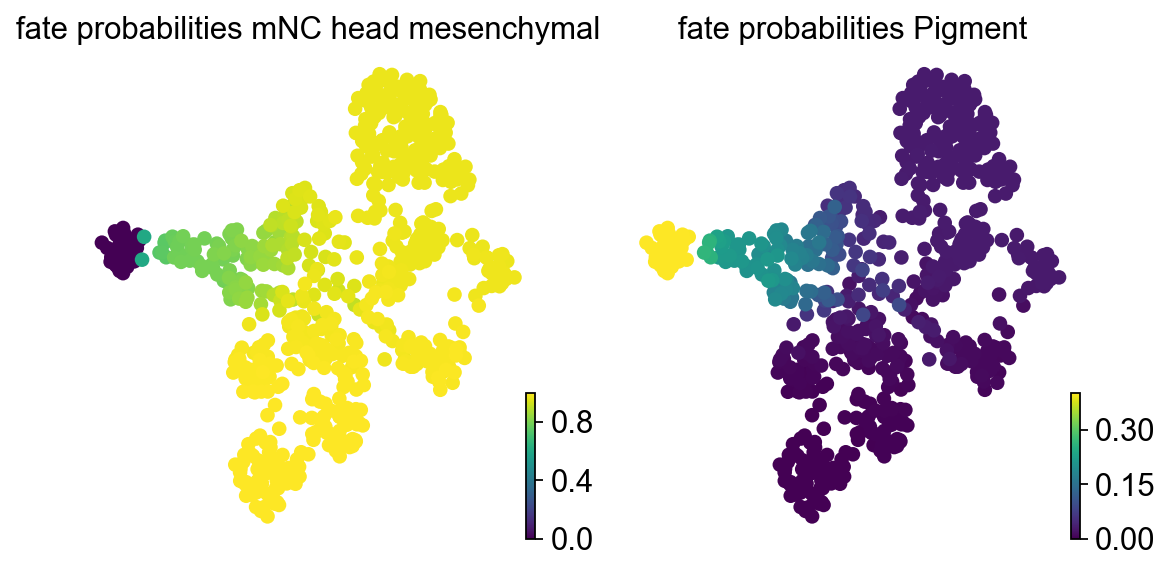

In [12]:
estimator.plot_fate_probabilities(
    same_plot=False,
    basis="umap",
)

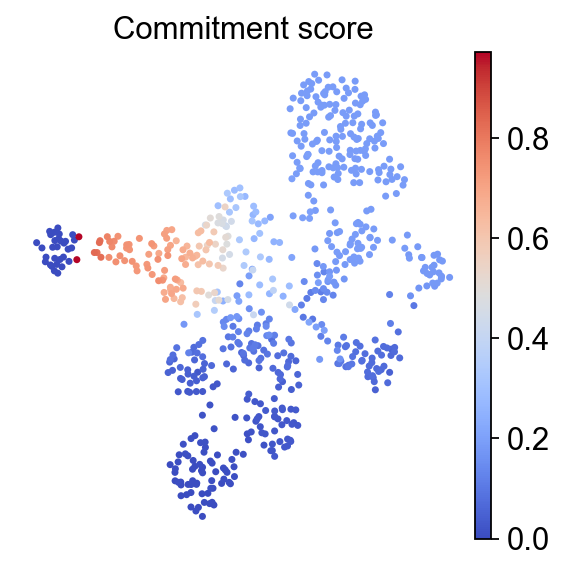

In [13]:
rgv.pl.commitment_score(
    adata=adata,
    lineage_key="lineages_fwd",
    frameon=False,
    s=40,
    cmap="coolwarm",
    title="Commitment score",
)

## RegVelo 原生 TF regulon blockade

复现流程会使用保存的 RegVelo model 做 TF perturbation 和 regulatory screening。由于模型已经保存到 `RESULT_DIR / "model"`，这里直接调用 RegVelo 原生的 in silico blockade API。

In [14]:
candidate_tfs = [tf for tf in ["elf1", "nr2f5", "tfap2a", "sox10", "mitfa"] if tf in regulators]
if not candidate_tfs:
    raise ValueError("None of the candidate perturbation TFs survived RegVelo preprocessing.")

candidate_tf = candidate_tfs[0]
print("candidate TFs:", candidate_tfs)
print("single TF blockade:", candidate_tf)

perturbed_adata, perturbed_model = ov.single.Velo(adata).regvelo_perturb(
    candidate_tf,
    model=str(RESULT_DIR / "model"),
    cutoff=0.001,
    batch_size=adata.n_obs,
)

perturbed_velo = ov.single.Velo(perturbed_adata)
perturbed_velo.velocity_graph(vkey="velocity", xkey="Ms", n_jobs=4)
perturbed_velo.velocity_embedding(basis="umap", vkey="velocity")
print(perturbed_adata)

candidate TFs: ['elf1', 'nr2f5', 'tfap2a', 'sox10', 'mitfa']
single TF blockade: elf1
In Velo module, you should keep all genes' expression not normalized.
INFO     File result/regvelo_infer_grn/model/model.pt already downloaded                                           


In Velo module, you should keep all genes' expression not normalized.
computing velocity graph (using 4/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
AnnData object with n_obs × n_vars = 697 × 997
    obs: 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'cell_type', 'stage', 'velo_regvelo_self_transition', 'regvelo_latent_time', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'commitment_score', 'velocity_self_transition'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'is_tf', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'fit_beta', 'fit_gamma', 'fit_scaling', 'velo_regvelo_genes'
    uns: 'cell_type_colors', 'grnboost2_prior', 'grnboost2_prior_params', 'neighbors', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'velocity_params', 'regulators', 'targets', 'skeleton', 'network', 'regvelo_prepare', '

## 比较扰动前后的 velocity field

扰动后复用相同 UMAP 坐标，比较 baseline RegVelo vector field 和 TF blockade 后的 vector field。

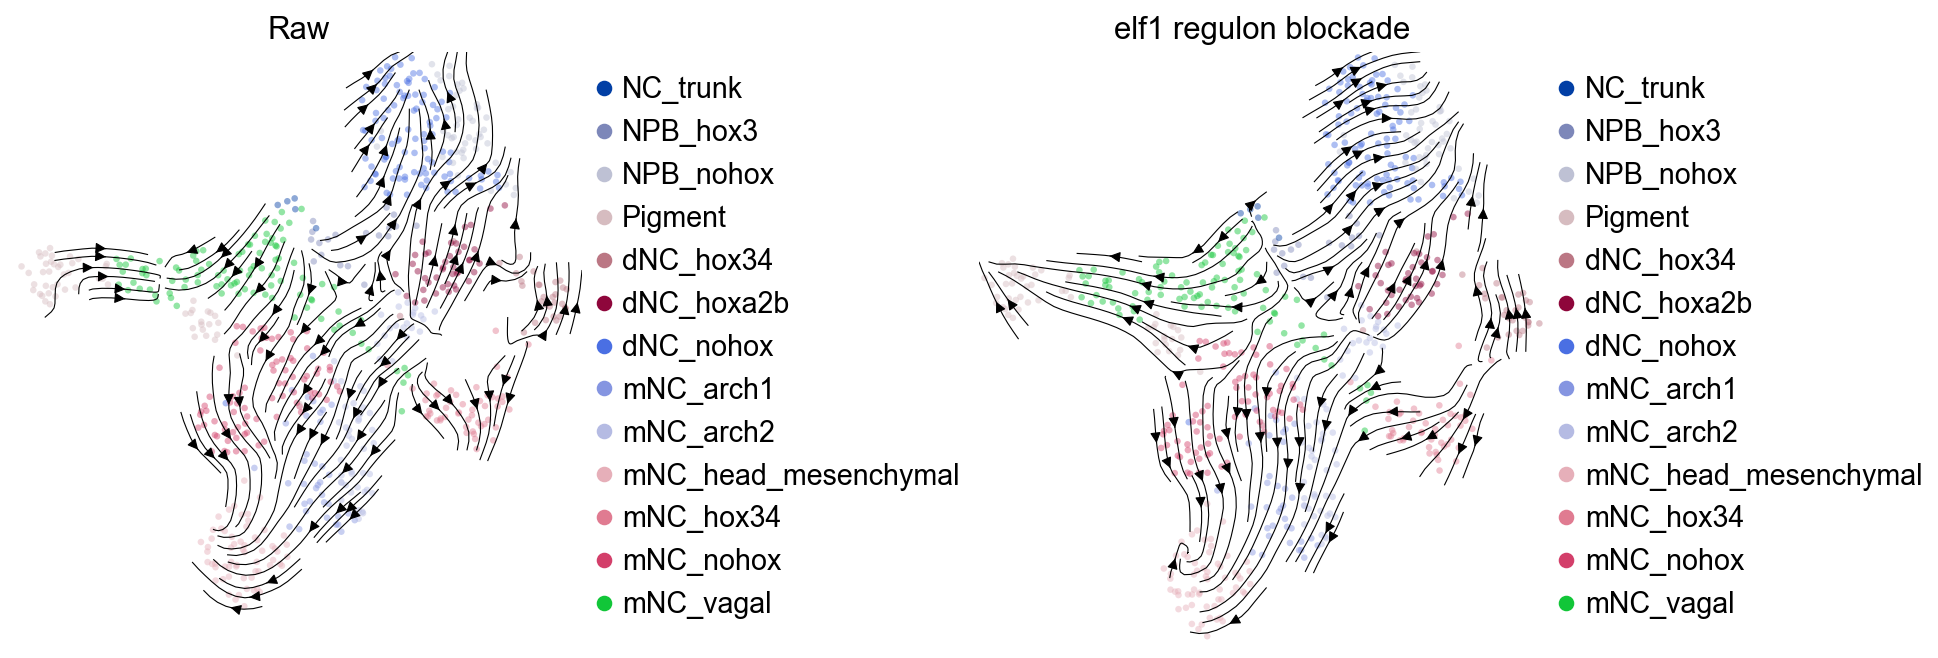

In [15]:
fig, axes = ov.plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[0],
    show=False,
    size=35,
    alpha=0.45,
    frameon=False,
)
ov.pl.add_streamplot(
    adata,
    basis="X_umap",
    velocity_key="velo_regvelo_umap",
    ax=axes[0],
)
axes[0].set_title("Raw")

ov.pl.embedding(
    perturbed_adata,
    basis="X_umap",
    color="cell_type",
    ax=axes[1],
    show=False,
    size=35,
    alpha=0.45,
    frameon=False,
)
ov.pl.add_streamplot(
    perturbed_adata,
    basis="X_umap",
    velocity_key="velocity_umap",
    ax=axes[1],
)
axes[1].set_title(f"{candidate_tf} regulon blockade")
ov.plt.show()

## 量化局部 TF blockade 效应

`ov.single.velocity_effect()` 会计算扰动前后每个细胞的 velocity cosine dissimilarity。数值越大，表示 TF blockade 后 velocity 方向改变越明显。

In Velo module, you should keep all genes' expression not normalized.


                mean    median       max
cell_type                               
mNC_vagal   0.000239  0.000172  0.000645
Pigment     0.000153  0.000123  0.000396
NC_trunk    0.000144  0.000128  0.000284
NPB_hox3    0.000143  0.000133  0.000477
dNC_hoxa2b  0.000131  0.000112  0.000398
mNC_nohox   0.000122  0.000111  0.000247
NPB_nohox   0.000115  0.000106  0.000235
mNC_arch2   0.000110  0.000095  0.000464
dNC_hox34   0.000103  0.000095  0.000247
mNC_hox34   0.000103  0.000088  0.000260

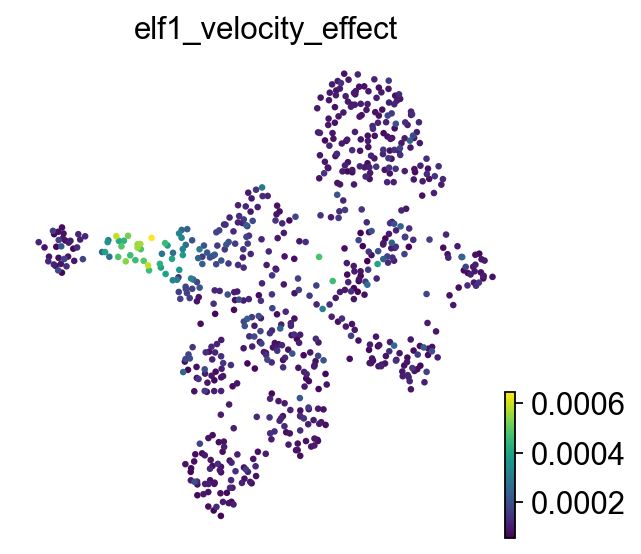

In [16]:
ov.single.velocity_effect(
    adata,
    perturbed_adata,
    baseline_velocity_key="velo_regvelo",
    perturbed_velocity_key="velocity",
    target=candidate_tf,
)

effect_col = f"{candidate_tf}_velocity_effect"
velocity_effect_summary = (
    adata.obs.groupby("cell_type", observed=True)[effect_col]
    .agg(["mean", "median", "max"])
    .sort_values("mean", ascending=False)
)
display(velocity_effect_summary.head(10))

ov.pl.embedding(
    adata,
    basis="X_umap",
    color=effect_col,
    cmap="viridis",
    size=35,
    frameon=False,
)

## 比较扰动前后的 fate probabilities

在扰动后的 velocity field 上重新计算 CellRank fate probabilities，并比较 terminal-state probability 的变化。

In Velo module, you should keep all genes' expression not normalized.


  0%|          | 0/697 [00:00<?, ?cell/s]

  0%|          | 0/697 [00:00<?, ?cell/s]

perturbed terminal states used: ['mNC_head_mesenchymal', 'Pigment']
perturbed macrostates: ['mNC_hox34', 'Pigment', 'dNC_nohox', 'mNC_head_mesenchymal']


                      elf1_delta_mNC_head_mesenchymal  elf1_delta_Pigment
cell_type                                                                
NC_trunk                                    -0.360737            0.360737
NPB_hox3                                    -0.313819            0.313819
NPB_nohox                                   -0.289084            0.289084
Pigment                                     -0.326127            0.326127
dNC_hox34                                   -0.272986            0.272986
dNC_hoxa2b                                  -0.278730            0.278730
dNC_nohox                                   -0.287282            0.287282
mNC_arch1                                   -0.023410            0.023410
mNC_arch2                                   -0.062895            0.062895
mNC_head_mesenchymal                        -0.001560            0.001560
mNC_hox34                                   -0.095260            0.095260
mNC_nohox                             

plotted fate delta: elf1_delta_Pigment


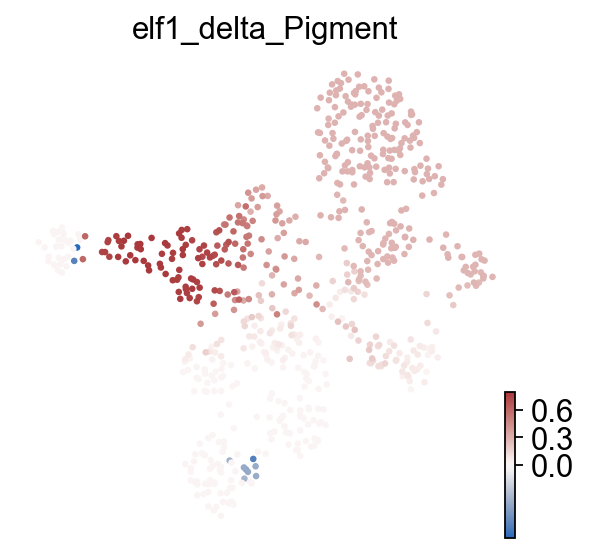

In [17]:
def lineage_to_df(adata_obj, key="lineages_fwd"):
    lineages = adata_obj.obsm[key]
    values = np.asarray(lineages)
    names = getattr(lineages, "names", None)
    if names is None:
        names = [f"lineage_{i}" for i in range(values.shape[1])]
    return pd.DataFrame(values, index=adata_obj.obs_names, columns=list(names))

perturbed_estimator = ov.single.cellrank_fate(
    perturbed_adata,
    velocity_key="velocity",
    xkey="Ms",
    cluster_key="cell_type",
    terminal_states=terminal_states,
    n_states=max(4, len(terminal_states)),
    n_cells=30,
    connectivity_weight=0.2,
    compute_fate_probabilities=True,
    fate_kwargs={"solver": "direct", "use_petsc": False},
    clean=True,
    plot=False,
)

perturbed_macrostate_names = ov.single.state_names(perturbed_estimator)
perturbed_terminal_states = list(
    perturbed_adata.uns["velocity_cellrank"].get("terminal_states") or []
)
if not perturbed_terminal_states:
    raise ValueError(
        f"None of the baseline terminal states are perturbed CellRank macrostates. "
        f"Valid perturbed macrostates: {perturbed_macrostate_names}"
    )

print("perturbed terminal states used:", perturbed_terminal_states)
print("perturbed macrostates:", perturbed_macrostate_names)

# RegVelo native perturbation metrics read fate probabilities directly from
# lineages_fwd. Clean non-finite entries explicitly before computing deltas
# and likelihood/t-statistic summaries.
ov.single.clean_lineages(adata, key="lineages_fwd")
ov.single.clean_lineages(perturbed_adata, key="lineages_fwd")

baseline_fate = lineage_to_df(adata)
perturbed_fate = lineage_to_df(perturbed_adata)
common_fates = list(baseline_fate.columns.intersection(perturbed_fate.columns))
if not common_fates:
    raise ValueError("No common fate probability columns were found between baseline and perturbed CellRank results.")
terminal_states_for_perturbation = common_fates

fate_delta = perturbed_fate[common_fates] - baseline_fate[common_fates]
fate_delta.columns = [f"{candidate_tf}_delta_{state}" for state in common_fates]
adata.obs = adata.obs.join(fate_delta)

fate_delta_summary = fate_delta.groupby(adata.obs["cell_type"], observed=True).mean()
display(fate_delta_summary)

target_fate = "Pigment" if "Pigment" in common_fates else common_fates[0]
target_delta_col = f"{candidate_tf}_delta_{target_fate}"
print("plotted fate delta:", target_delta_col)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color=target_delta_col,
    cmap="vlag",
    vcenter=0,
    size=35,
    frameon=False,
)

RegVelo 也提供原生的 fate perturbation 统计函数，用于汇总 fate probability depletion/enrichment。当前 RegVelo 版本会要求 baseline 和 perturbed 的 `lineages_fwd` 使用完全相同的 terminal-state 列；因此下面先在临时 AnnData 副本中裁剪 lineage columns，再调用 `ov.single.cell_fate_perturbation()`。

In Velo module, you should keep all genes' expression not normalized.


   Depletion likelihood       p-value  FDR adjusted p-value  \
0              0.769835  1.926251e-68          3.852503e-68   
1              0.230165  1.000000e+00          1.000000e+00   

         Terminal state    TF  
0  mNC_head_mesenchymal  elf1  
1               Pigment  elf1  

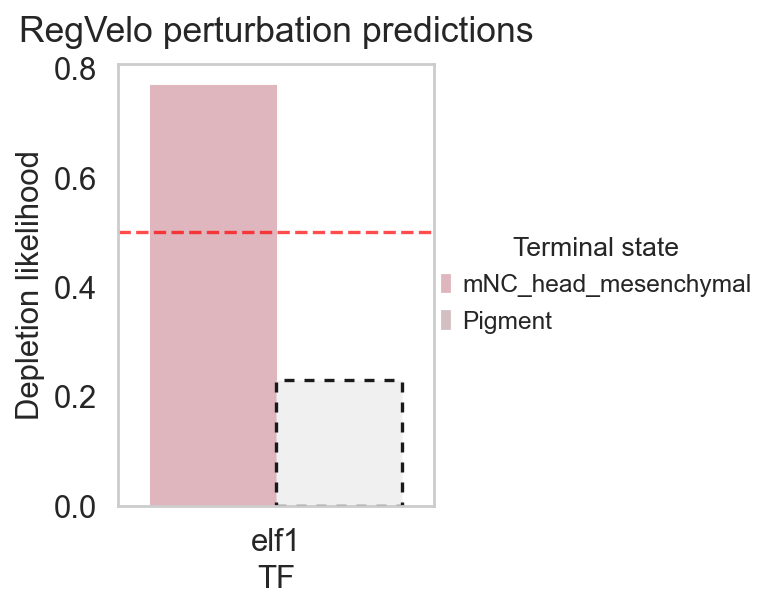

In [18]:
from cellrank import Lineage


def subset_lineages(adata_obj, names, key="lineages_fwd"):
    lineages = adata_obj.obsm[key]
    old_names = list(getattr(lineages, "names", [f"lineage_{i}" for i in range(np.asarray(lineages).shape[1])]))
    keep = [name for name in names if name in old_names]
    if not keep:
        raise ValueError("No requested lineage columns were found.")
    idx = [old_names.index(name) for name in keep]
    values = np.asarray(lineages, dtype=float)[:, idx]
    values = np.nan_to_num(values, nan=0.0, posinf=0.0, neginf=0.0)
    row_sums = values.sum(axis=1, keepdims=True)
    nonzero = row_sums[:, 0] > 0
    values[nonzero] = values[nonzero] / row_sums[nonzero]
    values[~nonzero] = 1.0 / values.shape[1]
    colors = getattr(lineages, "colors", None)
    if colors is not None:
        colors = [colors[i] for i in idx]
    adata_obj.obsm[key] = Lineage(values, names=keep, colors=colors)
    return keep

baseline_metric = adata.copy()
perturbed_metric = perturbed_adata.copy()
metric_terminal_states = subset_lineages(baseline_metric, terminal_states_for_perturbation)
subset_lineages(perturbed_metric, metric_terminal_states)

fate_stats = ov.single.cell_fate_perturbation(
    baseline_metric,
    perturbed={candidate_tf: perturbed_metric},
    terminal_states=metric_terminal_states,
    score_method="likelihood",
)
display(fate_stats)

rgv.pl.cellfate_perturbation(
    adata=baseline_metric,
    df=fate_stats,
    color_label="cell_type",
    figsize=(5, 4),
)

## Single-cell perturbation effect

`ov.single.perturbation_effect()` 会把每个细胞的 fate probability 差异写回 `adata.obs`。负值表示朝某个 terminal fate 的 probability 降低，正值表示升高。

In [19]:
adata = ov.single.perturbation_effect(
    adata,
    perturbed_adata,
    terminal_states=terminal_states_for_perturbation,
)

effect_cols = [col for col in adata.obs.columns if col.startswith("perturbation effect on ")]
print(effect_cols)

In Velo module, you should keep all genes' expression not normalized.
['perturbation effect on mNC_head_mesenchymal', 'perturbation effect on Pigment']


                      perturbation effect on mNC_head_mesenchymal  \
cell_type                                                           
NC_trunk                                                -0.360737   
NPB_hox3                                                -0.313819   
NPB_nohox                                               -0.289084   
Pigment                                                 -0.326127   
dNC_hox34                                               -0.272986   
dNC_hoxa2b                                              -0.278730   
dNC_nohox                                               -0.287282   
mNC_arch1                                               -0.023410   
mNC_arch2                                               -0.062895   
mNC_head_mesenchymal                                    -0.001560   
mNC_hox34                                               -0.095260   
mNC_nohox                                               -0.128186   
mNC_vagal                         

plotted perturbation effect: perturbation effect on Pigment


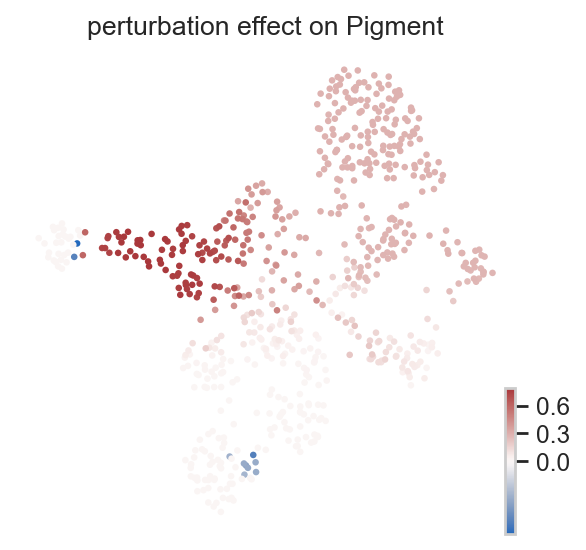

In [20]:
perturbation_effect_summary = (
    adata.obs.groupby("cell_type", observed=True)[effect_cols]
    .mean()
    .sort_index()
)
display(perturbation_effect_summary)

preferred_effect = "perturbation effect on Pigment"
effect_key = preferred_effect if preferred_effect in effect_cols else effect_cols[0]
print("plotted perturbation effect:", effect_key)

ov.pl.embedding(
    adata,
    basis="X_umap",
    color=effect_key,
    cmap="vlag",
    vcenter=0,
    size=35,
    frameon=False,
)

## 多个 TF 同时 blockade

`regvelo_perturb()` 的 `tf` 参数也可以传入多个 TF。多 TF 组合扰动通常用于探索协同调控，但建议先确认这些 TF 都在当前模型保留的 regulator 列表中。

In [21]:
multi_tfs = [tf for tf in ["elf1", "nr2f5", "tfap2a", "sox10", "mitfa"] if tf in regulators][:2]
print("multi TF blockade:", multi_tfs)

multi_perturbed_adata, multi_perturbed_model = ov.single.Velo(adata).regvelo_perturb(
    multi_tfs,
    model=str(RESULT_DIR / "model"),
    cutoff=0.001,
    batch_size=adata.n_obs,
)

multi_perturbed_velo = ov.single.Velo(multi_perturbed_adata)
multi_perturbed_velo.velocity_graph(vkey="velocity", xkey="Ms", n_jobs=4)
multi_perturbed_velo.velocity_embedding(basis="umap", vkey="velocity")

multi TF blockade: ['elf1', 'nr2f5']
In Velo module, you should keep all genes' expression not normalized.
INFO     File result/regvelo_infer_grn/model/model.pt already downloaded                                           


In Velo module, you should keep all genes' expression not normalized.
computing velocity graph (using 4/12 cores)


  0%|          | 0/697 [00:00<?, ?cells/s]

    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


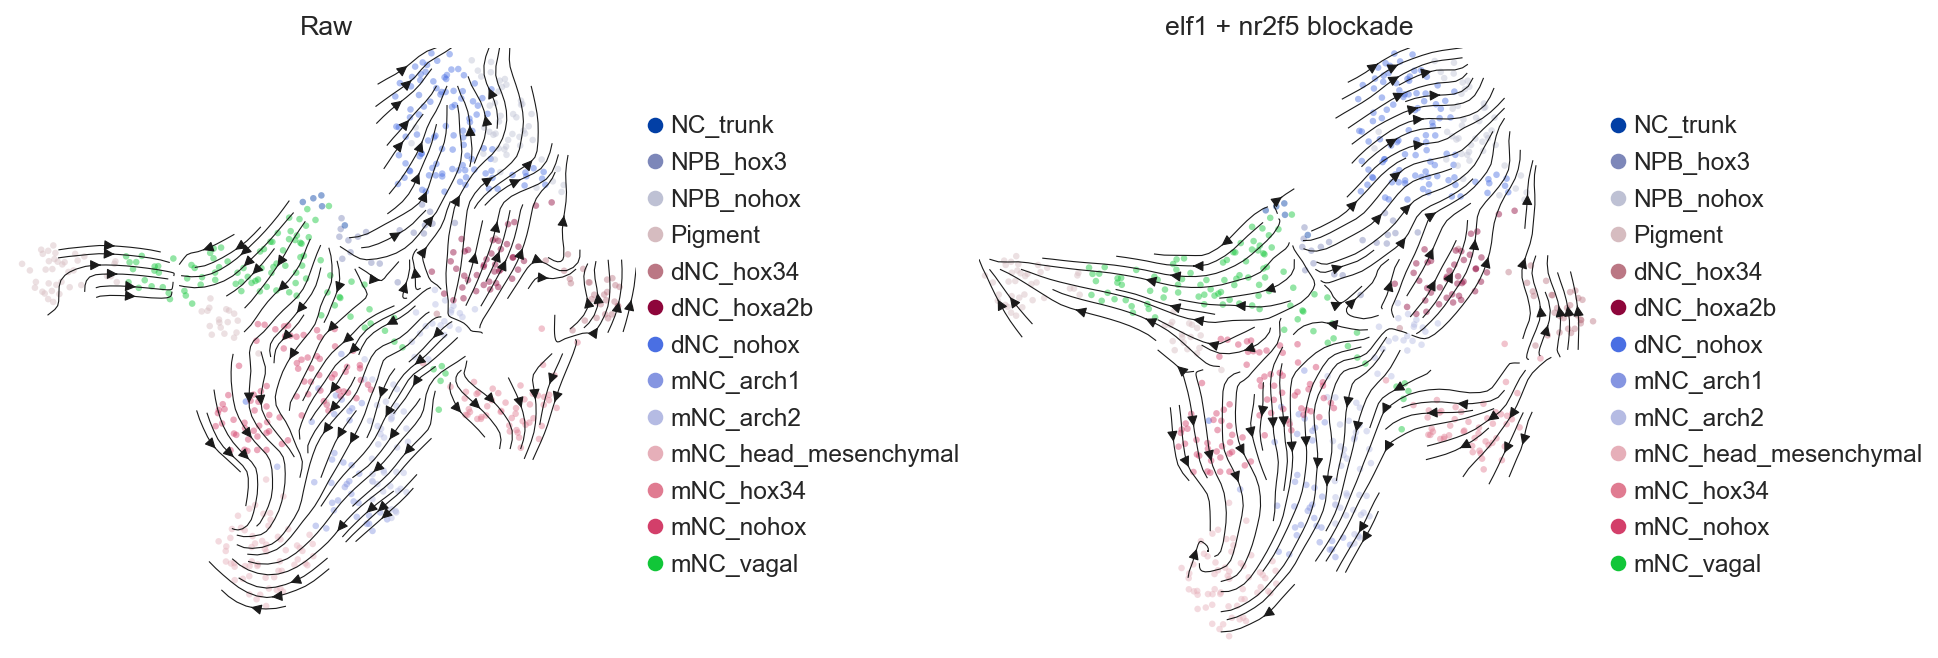

In [22]:
fig, axes = ov.plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ov.pl.embedding(adata, basis="X_umap", color="cell_type", ax=axes[0], show=False, size=35, alpha=0.45, frameon=False)
ov.pl.add_streamplot(adata, basis="X_umap", velocity_key="velo_regvelo_umap", ax=axes[0])
axes[0].set_title("Raw")

ov.pl.embedding(
    multi_perturbed_adata,
    basis="X_umap", color="cell_type",
    ax=axes[1],
    show=False,
    size=35,
    alpha=0.45,
    frameon=False
)
ov.pl.add_streamplot(multi_perturbed_adata, basis="X_umap", velocity_key="velocity_umap", ax=axes[1])
axes[1].set_title(" + ".join(multi_tfs) + " blockade")
ov.plt.show()

## 保存结果

保存的 AnnData 包含 `Ms`、`Mu`、`velo_regvelo`、RegVelo metadata、CellRank fate probabilities、TF perturbation summaries 和 single-cell perturbation effects。CellRank estimator/kernel 对象、内存中的 RegVelo model 和 perturbation AnnData 不能直接写入 h5ad，因此保存前需要先清理这些对象。

In [23]:
adata_to_save = adata.copy()
adata_to_save.uns["velocity_cellrank"] = {
    key: value
    for key, value in adata_to_save.uns["velocity_cellrank"].items()
    if key not in {"estimator", "kernel"}
}

adata_to_save.uns.pop("regvelo_model", None)

adata_to_save.write(RESULT_DIR / "zebrafish_regvelo_infer_grn.h5ad")
print(RESULT_DIR / "zebrafish_regvelo_infer_grn.h5ad")

result/regvelo_infer_grn/zebrafish_regvelo_infer_grn.h5ad
